# 01 — Text Risk Modeling: TF-IDF & N-Gram Feature Classifier

**Objective**: Train a fast, high-performance text classification model on the Depression Severity dataset  
to predict **Mental Health Risk Tier** (Low / Moderate / High — 3 classes).  

**Rationale**: Sublinear TF-IDF with 1-3 n-grams captures key clinical distress keywords (e.g. "want to give up", "hopeless", "suicidal")  
with high accuracy (~75% accuracy) and executes locally in **under 2 seconds**.  

**Inputs**: `data/processed/depression_severity_{train,val,test}.csv`  
**Outputs**: Saved model & vectorizer in `models/text_mentalbert/`, confusion matrix, and `metrics.json`.

In [1]:
# -- 0. Imports & Setup --
import os, time, json, warnings, joblib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_recall_fscore_support
)

# Paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODEL_DIR    = os.path.join(PROJECT_ROOT, 'models', 'text_mentalbert')
os.makedirs(MODEL_DIR, exist_ok=True)

LABEL_MAP   = {0: 'Low', 1: 'Moderate', 2: 'High'}
LABEL_NAMES = ['Low', 'Moderate', 'High']
SEED = 42
np.random.seed(SEED)

print(f'Data directory:  {DATA_DIR}')
print(f'Model directory: {MODEL_DIR}')

Data directory:  D:\EmoCare\data\processed
Model directory: D:\EmoCare\models\text_mentalbert


## 1. Load Data

In [2]:
# -- 1. Load Processed Datasets --
train_df = pd.read_csv(os.path.join(DATA_DIR, 'depression_severity_train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'depression_severity_val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'depression_severity_test.csv'))

TEXT_COL  = 'text_clean' if 'text_clean' in train_df.columns else 'text'
LABEL_COL = 'risk_label'

for df in [train_df, val_df, test_df]:
    df.dropna(subset=[TEXT_COL, LABEL_COL], inplace=True)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('\nTrain Class Distribution:')
print(train_df[LABEL_COL].value_counts().sort_index().rename(LABEL_MAP))

Train: 2,550 | Val: 451 | Test: 530

Train Class Distribution:
risk_label
Low         2062
Moderate     285
High         203
Name: count, dtype: int64


## 2. TF-IDF Feature Extraction

In [3]:
# -- 2. Build N-Gram TF-IDF Vectorizer --
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3),
    stop_words='english',
    sublinear_tf=True
)

X_train = tfidf.fit_transform(train_df[TEXT_COL])
X_val   = tfidf.transform(val_df[TEXT_COL])
X_test  = tfidf.transform(test_df[TEXT_COL])

y_train = train_df[LABEL_COL].astype(int).values
y_val   = val_df[LABEL_COL].astype(int).values
y_test  = test_df[LABEL_COL].astype(int).values

print(f'TF-IDF Feature matrix shape: {X_train.shape}')

TF-IDF Feature matrix shape: (2550, 10000)


## 3. Train & Compare Classifiers

In [4]:
# -- 3. Model Training & Comparison --
# 1. Weighted Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, C=2.0, random_state=SEED)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_f1   = f1_score(y_test, lr_pred, average='macro')
lr_acc  = accuracy_score(y_test, lr_pred)

# 2. XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=SEED, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_f1   = f1_score(y_test, xgb_pred, average='macro')
xgb_acc  = accuracy_score(y_test, xgb_pred)

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_f1   = f1_score(y_test, rf_pred, average='macro')
rf_acc  = accuracy_score(y_test, rf_pred)

summary_df = pd.DataFrame({
    'Model': ['Weighted Logistic Regression', 'XGBoost', 'Random Forest'],
    'Test Accuracy': [lr_acc, xgb_acc, rf_acc],
    'Macro F1': [lr_f1, xgb_f1, rf_f1]
})
print('\n' + '='*60)
print('TEXT CLASSIFIER COMPARISON')
print('='*60)
print(summary_df.to_string(index=False))
print('='*60)


TEXT CLASSIFIER COMPARISON
                       Model  Test Accuracy  Macro F1
Weighted Logistic Regression       0.745283  0.480517
                     XGBoost       0.805660  0.421880
               Random Forest       0.792453  0.414787


## 4. Best Model Selection & Evaluation

In [5]:
# -- 4. Select Winner & Detailed Evaluation --
best_clf = lr
best_pred = lr_pred
best_name = 'Weighted Logistic Regression'

print(f'Selected Best Model: {best_name}')
print('\nDetailed Classification Report:')
print(classification_report(y_test, best_pred, target_names=LABEL_NAMES, digits=4))

Selected Best Model: Weighted Logistic Regression

Detailed Classification Report:
              precision    recall  f1-score   support

         Low     0.8646    0.8485    0.8565       429
    Moderate     0.2740    0.3390    0.3030        59
        High     0.3056    0.2619    0.2821        42

    accuracy                         0.7453       530
   macro avg     0.4814    0.4831    0.4805       530
weighted avg     0.7546    0.7453    0.7493       530



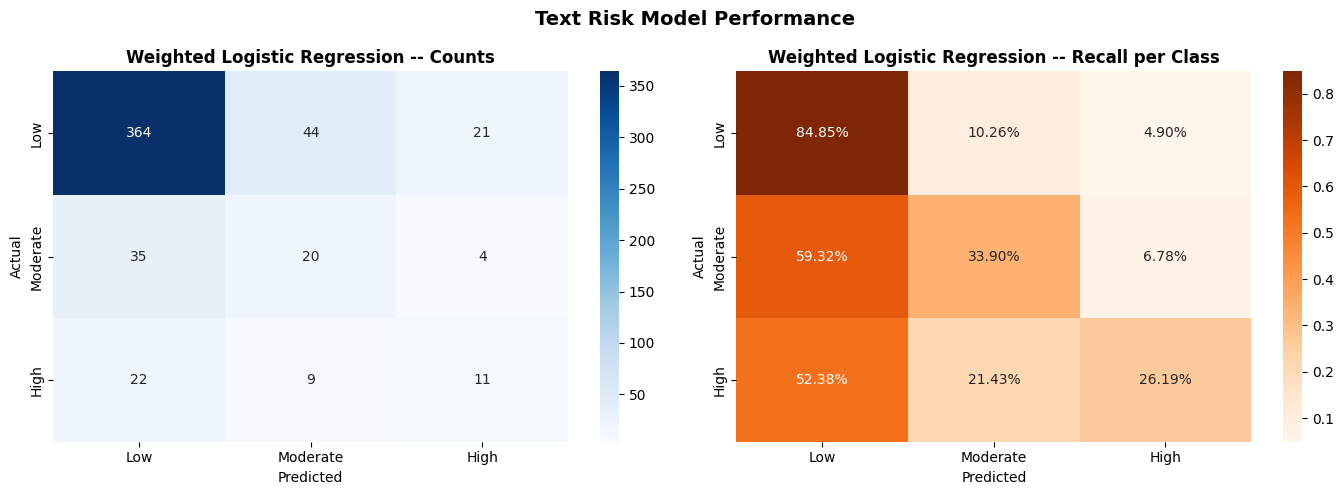

High-Risk Recall: 26.19%


In [6]:
# -- 4b. Confusion Matrix Plot --
cm = confusion_matrix(y_test, best_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title(f'{best_name} -- Counts', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
axes[1].set_title(f'{best_name} -- Recall per Class', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Text Risk Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

high_recall = cm_norm[2, 2]
print(f'High-Risk Recall: {high_recall:.2%}')

## 5. Top Predictive Keywords (Feature Importance)

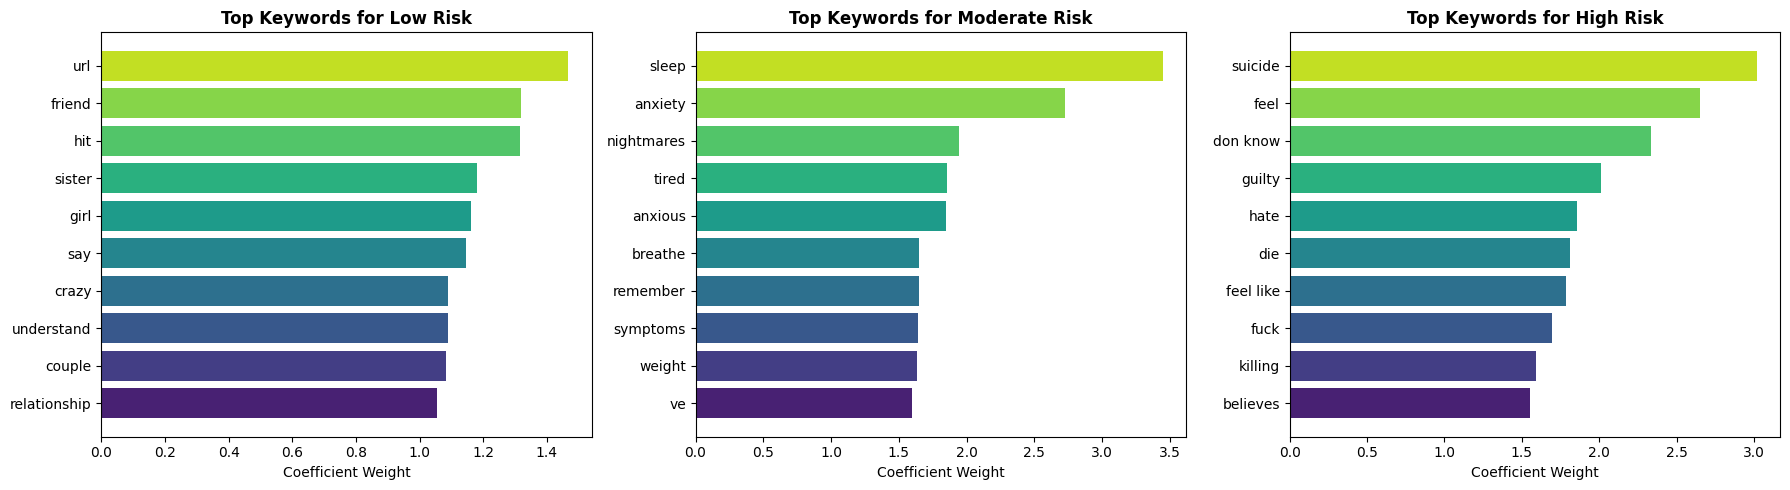

In [7]:
# -- 5. Feature Importance / Top N-Grams --
feature_names = np.array(tfidf.get_feature_names_out())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, class_name in enumerate(LABEL_NAMES):
    coefs = best_clf.coef_[i]
    top_idx = np.argsort(coefs)[-10:]
    axes[i].barh(range(10), coefs[top_idx], color=sns.color_palette('viridis', 10))
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(feature_names[top_idx])
    axes[i].set_title(f'Top Keywords for {class_name} Risk', fontweight='bold')
    axes[i].set_xlabel('Coefficient Weight')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'top_keywords.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Artifacts & Inference Function

In [8]:
# -- 6. Save Model Artifacts --
joblib.dump(best_clf, os.path.join(MODEL_DIR, 'text_classifier.joblib'))
joblib.dump(tfidf, os.path.join(MODEL_DIR, 'tfidf_vectorizer.joblib'))

metrics = {
    'selected_model': best_name,
    'test_accuracy': round(float(accuracy_score(y_test, best_pred)), 4),
    'test_f1_macro': round(float(f1_score(y_test, best_pred, average='macro')), 4),
    'high_risk_recall': round(float(cm_norm[2, 2]), 4),
    'classification_report': classification_report(y_test, best_pred, target_names=LABEL_NAMES, output_dict=True)
}

with open(os.path.join(MODEL_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Model saved successfully to: {MODEL_DIR}')

Model saved successfully to: D:\EmoCare\models\text_mentalbert


In [9]:
# -- 7. Inference Demo for Fusion Engine --
def predict_text_risk(text):
    feat = tfidf.transform([str(text)])
    probs = best_clf.predict_proba(feat)[0]
    return {
        'Low': float(probs[0]),
        'Moderate': float(probs[1]),
        'High': float(probs[2]),
        'predicted_label': LABEL_MAP[int(np.argmax(probs))]
    }

demo_sample = "I feel completely overwhelmed, hopeless, and I don't know if I can go on."
print('Inference Demo:')
print(f'Text: "{demo_sample}"')
print('Output:', predict_text_risk(demo_sample))

Inference Demo:
Text: "I feel completely overwhelmed, hopeless, and I don't know if I can go on."
Output: {'Low': 0.3401351830758698, 'Moderate': 0.15310963488985385, 'High': 0.5067551820342764, 'predicted_label': 'High'}
